In [1]:
!pip install datasets pillow


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
from datasets import load_dataset_builder

# Configuration
DATASET_REPO = "danielz01/fMoW"

# Paste your Hugging Face token here (or set it as an environment variable)
HF_TOKEN = os.environ.get("HF_TOKEN")

print(f"Fetching metadata for gated dataset '{DATASET_REPO}'...")

try:
    # Pass the token directly to authenticate the request
    ds_builder = load_dataset_builder(DATASET_REPO, token=HF_TOKEN)
    
    if "label" in ds_builder.info.features:
        label_feature = ds_builder.info.features["label"]
        
        if hasattr(label_feature, "names"):
            labels = label_feature.names
            print(f"\nFound {len(labels)} unique labels in the dataset:\n")
            
            for i in range(0, len(labels), 4):
                print(", ".join(f"'{lbl}'" for lbl in labels[i:i+4]))
        else:
            print(f"\nFeature details: {label_feature}")
    else:
        print("Available columns:", list(ds_builder.info.features.keys()))

except Exception as e:
    print(f"\nAuthentication failed or error occurred: {e}")
    print("Please verify your token and ensure you accepted the terms on the Hugging Face website.")

Fetching metadata for gated dataset 'danielz01/fMoW'...

Found 62 unique labels in the dataset:

'airport', 'airport_hangar', 'airport_terminal', 'amusement_park'
'aquaculture', 'archaeological_site', 'barn', 'border_checkpoint'
'burial_site', 'car_dealership', 'construction_site', 'crop_field'
'dam', 'debris_or_rubble', 'educational_institution', 'electric_substation'
'factory_or_powerplant', 'fire_station', 'flooded_road', 'fountain'
'gas_station', 'golf_course', 'ground_transportation_station', 'helipad'
'hospital', 'impoverished_settlement', 'interchange', 'lake_or_pond'
'lighthouse', 'military_facility', 'multi-unit_residential', 'nuclear_powerplant'
'office_building', 'oil_or_gas_facility', 'park', 'parking_lot_or_garage'
'place_of_worship', 'police_station', 'port', 'prison'
'race_track', 'railway_bridge', 'recreational_facility', 'road_bridge'
'runway', 'shipyard', 'shopping_mall', 'single-unit_residential'
'smokestack', 'solar_farm', 'space_facility', 'stadium'
'storage_tank',

In [3]:
import os
# Force Hugging Face to use your token globally
HF_TOKEN = os.environ.get("HF_TOKEN")

from datasets import load_dataset

# Configuration
DATASET_REPO = "danielz01/fMoW"
TARGET_COUNT = 500
OUTPUT_DIR_URBAN = "fMoW_dataset/urban"
OUTPUT_DIR_NATURAL = "fMoW_dataset/natural"

# Explicit mapping based on your printed dataset labels
URBAN_LABELS = {
    "airport_terminal", "construction_site", "factory_or_powerplant", 
    "interchange", "multi-unit_residential", "office_building", 
    "shopping_mall", "single-unit_residential", "skyscrapers"
}

NATURAL_LABELS = {
    "lake_or_pond", "crop_field", "golf_course", "flooded_road", 
    "park", "zoo"
}

def download_streamed_dataset():
    # Setup local storage folders
    os.makedirs(OUTPUT_DIR_URBAN, exist_ok=True)
    os.makedirs(OUTPUT_DIR_NATURAL, exist_ok=True)
    
    urban_count = 0
    natural_count = 0
    
    print(f"Connecting to Hugging Face Hub: {DATASET_REPO}...")
    print("Streaming dataset... (Writing directly to folder stacks)")
    
    # Streaming mode avoids major disk space allocations
    dataset_stream = load_dataset(DATASET_REPO, split="train", streaming=True, token=HF_TOKEN)
    
    # Grab the feature configuration to map integers back to string labels
    features = dataset_stream.features
    label_names = features["label"].names

    for idx, item in enumerate(dataset_stream):
        # Break early once targets are met to preserve bandwidth
        if urban_count >= TARGET_COUNT and natural_count >= TARGET_COUNT:
            break
            
        image = item.get("image") or item.get("img")
        raw_label = item.get("label")
        
        if image is None or raw_label is None:
            continue
            
        # Map integer label IDs back to their explicit string names
        label_str = label_names[raw_label].strip().lower()
        
        # Process Urban matches
        if label_str in URBAN_LABELS and urban_count < TARGET_COUNT:
            urban_count += 1
            filename = f"urban_{urban_count}_{idx}.jpg"
            # Ensure image is in standard RGB layout before string compression save
            image.convert("RGB").save(os.path.join(OUTPUT_DIR_URBAN, filename))
            print(f"[Urban: {urban_count}/{TARGET_COUNT}] Saved {filename} (Class: {label_str})")
            
        # Process Natural/Open Space matches
        elif label_str in NATURAL_LABELS and natural_count < TARGET_COUNT:
            natural_count += 1
            filename = f"natural_{natural_count}_{idx}.jpg"
            image.convert("RGB").save(os.path.join(OUTPUT_DIR_NATURAL, filename))
            print(f"[Natural: {natural_count}/{TARGET_COUNT}] Saved {filename} (Class: {label_str})")

    print("\n--- Process Complete ---")
    print(f"Successfully collected {urban_count} images in fMoW_dataset/urban")
    print(f"Successfully collected {natural_count} images in fMoW_dataset/natural")

download_streamed_dataset()

Connecting to Hugging Face Hub: danielz01/fMoW...
Streaming dataset... (Writing directly to folder stacks)
[Urban: 1/500] Saved urban_1_1107.jpg (Class: multi-unit_residential)
[Urban: 2/500] Saved urban_2_1108.jpg (Class: multi-unit_residential)
[Urban: 3/500] Saved urban_3_1109.jpg (Class: multi-unit_residential)
[Urban: 4/500] Saved urban_4_1110.jpg (Class: multi-unit_residential)
[Urban: 5/500] Saved urban_5_1111.jpg (Class: multi-unit_residential)
[Urban: 6/500] Saved urban_6_1112.jpg (Class: multi-unit_residential)
[Urban: 7/500] Saved urban_7_1113.jpg (Class: multi-unit_residential)
[Urban: 8/500] Saved urban_8_1114.jpg (Class: multi-unit_residential)
[Urban: 9/500] Saved urban_9_1115.jpg (Class: multi-unit_residential)
[Urban: 10/500] Saved urban_10_1116.jpg (Class: multi-unit_residential)
[Urban: 11/500] Saved urban_11_1117.jpg (Class: multi-unit_residential)
[Urban: 12/500] Saved urban_12_1118.jpg (Class: multi-unit_residential)
[Urban: 13/500] Saved urban_13_1119.jpg (Class:

In [4]:
# Problem 3: Satellite Image Classification (Urban vs. Natural)
# Goal: Build a classical machine-learning system to classify satellite images into Urban or Natural categories.

# Required Concepts and Tools:
# Preprocessing: Resize, Grayscale, Histogram Equalization/CLAHE, Gaussian/Median smoothing
# Feature Extraction: Intensity histogram, LBP, Edge detection (Sobel/Canny), HOG, (Optional SIFT/ORB)
# Feature Selection: PCA or Variance thresholding
# ML Models: SVM, Random Forest, 5-fold cross-validation

# --- Setup and Installations ---
print("Installing necessary libraries...")
!pip install scikit-image scikit-learn numpy pandas matplotlib seaborn tqdm opencv-python

# --- Imports ---
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from skimage import exposure, feature, filters
from skimage.transform import resize
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm

print("Libraries installed and imported successfully.")

# --- Part 1 – Dataset Preparation ---
print("\n--- Part 1: Dataset Preparation ---")

# 1. Use the fMoW dataset.
# The fMoW dataset is very large. For this example, we'll outline the steps.
# You would typically download it from its official source or a Kaggle equivalent.
# For demonstration purposes, I will simulate dataset loading. If you have the fMoW dataset
# downloaded locally, please adjust the 'data_dir' path accordingly.

data_dir = '.\\fMoW_dataset'
urban_dir = os.path.join(data_dir, 'urban')
natural_dir = os.path.join(data_dir, 'natural')

# Placeholder for dataset download and extraction instructions if needed
# print("Please ensure the fMoW dataset is downloaded and extracted at: ", data_dir)
# print("For example, you might use Kaggle API or direct download: ")
# print("!kaggle datasets download -d fmow_dataset_path") # This is a hypothetical example
# print("!unzip fmow_dataset.zip -d ", data_dir)

# Create dummy image paths for demonstration if the actual dataset is not available
# In a real scenario, you would list actual image files.
num_urban_images = 500
num_natural_images = 500

def get_actual_image_paths(directory, max_images=500):
    """
    Scans the directory for actual existing images, normalizes paths 
    for OpenCV cross-platform safety, and limits the count to max_images.
    """
    if not os.path.exists(directory):
        print(f"Warning: Directory does not exist -> {os.path.abspath(directory)}")
        return []
    
    valid_extensions = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')
    
    # 1. Read what is actually inside the folder
    # 2. Convert to absolute path so OpenCV never encounters slash mismatches
    actual_paths = [
        os.path.abspath(os.path.join(directory, filename))
        for filename in os.listdir(directory)
        if filename.lower().endswith(valid_extensions)
    ]
    
    # Sort to ensure reproducibility and slice up to your target count
    return sorted(actual_paths)[:max_images]

# 2. Select up to 500 actual existing images each for Urban and Natural
urban_image_paths = get_actual_image_paths(urban_dir, max_images=num_urban_images)
natural_image_paths = get_actual_image_paths(natural_dir, max_images=num_natural_images)

# 2. Select ~500 images each for Urban and Natural.
# (Assumed by creating dummy paths, in a real scenario you would filter existing images)
print(f"Selected {len(urban_image_paths)} urban images and {len(natural_image_paths)} natural images (dummy paths).")

# Combine paths and create labels
all_image_paths = urban_image_paths + natural_image_paths
all_labels = ['urban'] * len(urban_image_paths) + ['natural'] * len(natural_image_paths)

# 3. Create an 80:20 train-test split.
# Using dummy paths, this split is illustrative.
# X will contain image paths, y will contain labels.
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Train set size: {len(X_train_paths)} images")
print(f"Test set size: {len(X_test_paths)} images")
print(f"Train labels distribution: Urban={y_train.count('urban')}, Natural={y_train.count('natural')}")
print(f"Test labels distribution: Urban={y_test.count('urban')}, Natural={y_test.count('natural')}")

# 4. Keep one external real-world image for final evaluation.
external_image_path = 'path/to/your/external_real_world_image.jpg'
print(f"Reserved one external image for final evaluation: {external_image_path}")

# Note: In a real scenario, you would implement a function to load images
# For now, we will proceed with the assumption that image paths are available.

print("Dataset preparation steps outlined. Proceed to the next section for image loading and preprocessing.")


Installing necessary libraries...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries installed and imported successfully.

--- Part 1: Dataset Preparation ---
Selected 500 urban images and 500 natural images (dummy paths).
Train set size: 800 images
Test set size: 200 images
Train labels distribution: Urban=400, Natural=400
Test labels distribution: Urban=100, Natural=100
Reserved one external image for final evaluation: path/to/your/external_real_world_image.jpg
Dataset preparation steps outlined. Proceed to the next section for image loading and preprocessing.


In [5]:
# --- Helper function to load and preprocess an image ---
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    # Simulate loading image since paths are dummy
    # In a real scenario, you'd use cv2.imread or skimage.io.imread
    # For now, let's create a dummy image for processing functions to work
    # This dummy image should be grayscale and of the target size.

    # Check if the path is a dummy path, if so, create a dummy image
    if 'dummy_data' in image_path:
        # Create a random grayscale image
        image = np.random.randint(0, 256, target_size, dtype=np.uint8)
    else:
        # Attempt to load a real image (will fail if path is invalid/image not found)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Warning: Could not load image from {image_path}. Using a dummy image instead.")
            image = np.random.randint(0, 256, (target_size[0], target_size[1], 3), dtype=np.uint8) # Create a 3-channel dummy

        # Resize
        image = resize(image, target_size, anti_aliasing=True)
        # Convert to 8-bit integer type for OpenCV/skimage functions
        image = (image * 255).astype(np.uint8)

    # Grayscale conversion
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    elif len(image.shape) == 2:
        image_gray = image # Already grayscale
    else:
        print(f"Warning: Image has unexpected shape {image.shape}. Assuming grayscale.")
        image_gray = image.astype(np.uint8)

    # Histogram Equalization / CLAHE
    # clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    # image_eq = clahe.apply(image_gray)
    # Using scikit-image's equalize_hist for simplicity if CLAHE is not preferred
    image_eq = exposure.equalize_hist(image_gray)
    image_eq = (image_eq * 255).astype(np.uint8)

    # Gaussian/Median smoothing
    image_smooth = filters.gaussian(image_eq, sigma=1, channel_axis=None)
    image_smooth = (image_smooth * 255).astype(np.uint8)

    return image_smooth

# --- Feature Engineering Functions ---

def extract_low_level_features(image):
    # Pixel Intensity Histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()

    # LBP Texture Patterns
    # Using 8 neighbors and 1 circular radius
    lbp = feature.local_binary_pattern(image, P=8, R=1, method="uniform")
    # Calculate histogram of LBP patterns
    (hist_lbp, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 8 + 3),
                                 range=(0, 8 + 2))
    hist_lbp = cv2.normalize(hist_lbp.astype("float"), hist_lbp.astype("float")).flatten()

    # Edge Detection (Canny)
    edges = feature.canny(image)
    # Count edge pixels as a simple edge feature
    edge_density = np.sum(edges) / (image.shape[0] * image.shape[1])

    return np.hstack([hist, hist_lbp, [edge_density]])

def extract_hog_features(image):
    # HOG Descriptors
    # Rescale image to a smaller size for HOG if it's too large, or if it's a dummy image.
    # HOG requires non-zero image dimension
    if image.shape[0] == 0 or image.shape[1] == 0:
        print("Warning: Empty image for HOG, returning zeros.")
        return np.zeros(324)

    # Ensure image is suitable for HOG (float and 0-1 range if using feature.hog)
    image_float = image.astype("float") / 255.0

    # HOG parameters (can be tuned)
    # For a 128x128 image, common block_norm='L2-Hys', pixels_per_cell=(8,8), cells_per_block=(2,2)
    # This results in a feature vector of size around (image_width/pixels_per_cell[0] - cells_per_block[0] + 1) * ... * 9 * cells_per_block[0] * cells_per_block[1]
    # For 128x128 with (8,8) cells and (2,2) blocks: (128/8 - 2 + 1) * (128/8 - 2 + 1) * 9 * 2 * 2 = 15*15*36 = 8100 features, which can be very large.
    # Let's use a simpler configuration for demonstration or a smaller image if memory is an issue.
    # For this example, let's use common values that result in a manageable feature vector size.
    # With pixels_per_cell=(16, 16) and cells_per_block=(1, 1), it would be (128/16)*(128/16)*9 = 8*8*9 = 576 features
    # Let's try with pixels_per_cell=(16, 16) and cells_per_block=(2, 2) and orientations=9
    # Resulting feature vector size: (image_width/cell_size[0] - block_size[0] + 1) * (image_height/cell_size[1] - block_size[1] + 1) * block_size[0] * block_size[1] * orientations
    # For 128x128, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9:
    # (128/16 - 2 + 1) * (128/16 - 2 + 1) * 2 * 2 * 9 = (8-2+1) * (8-2+1) * 4 * 9 = 7 * 7 * 36 = 1764 features
    # This is still quite large. Let's try with (32,32) and (2,2) or (16,16) and (1,1)
    # If pixels_per_cell=(16, 16) and cells_per_block=(1,1) (no overlapping blocks), then 8*8*9 = 576 features
    # Let's try (16,16) pixels_per_cell, (2,2) cells_per_block, 9 orientations as it's common, but will be large.
    # Alternatively, use a smaller image region if the HOG features are too dense.

    # Using smaller pixels_per_cell and cells_per_block for a more compact HOG feature vector for demonstration
    # (For production, these values might need tuning based on image content and desired feature density)
    # Example: pixels_per_cell=(32,32) and cells_per_block=(1,1) -> (128/32)*(128/32)*9 = 4*4*9 = 144 features
    hog_features = feature.hog(image_float, orientations=9,
                               pixels_per_cell=(16, 16), cells_per_block=(2, 2),
                               block_norm='L2-Hys', visualize=False)
    return hog_features

# --- Part 2 – Preprocessing & Part 3 – Feature Engineering ---
print("\n--- Part 2 & 3: Preprocessing and Feature Engineering ---")

# Prepare lists to store features and corresponding labels
X_features = []
y_labels = []

# Combine train and test paths for processing
all_paths_for_processing = X_train_paths + X_test_paths
all_labels_for_processing = list(y_train) + list(y_test) # Convert to list for concatenation

print(f"Processing {len(all_paths_for_processing)} images...")

# Loop through all image paths with a progress bar
for i, image_path in tqdm(enumerate(all_paths_for_processing), total=len(all_paths_for_processing)):
    # Preprocessing
    processed_image = load_and_preprocess_image(image_path)

    # Feature Engineering
    low_level_feats = extract_low_level_features(processed_image)
    hog_feats = extract_hog_features(processed_image)

    # Combine all features
    combined_features = np.hstack([low_level_feats, hog_feats])
    X_features.append(combined_features)
    y_labels.append(all_labels_for_processing[i])

X_features = np.array(X_features)
y_labels = np.array(y_labels)

print("Feature extraction complete.")
print(f"Shape of extracted features: {X_features.shape}")
print(f"Shape of labels: {y_labels.shape}")

# Re-split the features and labels into training and testing sets
# This ensures the features directly correspond to the original train/test split
X_train_feats, X_test_feats, y_train_labels, y_test_labels = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"Train features shape: {X_train_feats.shape}")
print(f"Test features shape: {X_test_feats.shape}")

# Store extracted features (e.g., as NumPy array for now)
# In a real application, you might save these to a file
# np.save('X_train_feats.npy', X_train_feats)
# np.save('X_test_feats.npy', X_test_feats)
# np.save('y_train_labels.npy', y_train_labels)
# np.save('y_test_labels.npy', y_test_labels)

print("Features are ready for selection and model training.")


--- Part 2 & 3: Preprocessing and Feature Engineering ---
Processing 1000 images...


  0%|          | 0/1000 [00:00<?, ?it/s]

Feature extraction complete.
Shape of extracted features: (1000, 2031)
Shape of labels: (1000,)
Train features shape: (800, 2031)
Test features shape: (200, 2031)
Features are ready for selection and model training.


In [6]:
# --- Part 4 – Feature Selection & Dimensionality Reduction ---
print("\n--- Part 4: Feature Selection ---")

# Scale features before applying PCA
# It's crucial to fit the scaler only on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)
X_test_scaled = scaler.transform(X_test_feats)

print(f"Original training features shape: {X_train_scaled.shape}")
print(f"Original testing features shape: {X_test_scaled.shape}")

# Apply PCA
# Let's aim to retain a certain percentage of variance, e.g., 95%.
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Number of components selected by PCA: {pca.n_components_}")
print(f"Cumulative explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

print(f"Training features shape after PCA: {X_train_pca.shape}")
print(f"Testing features shape after PCA: {X_test_pca.shape}")

# Store the processed features (optional, but good practice)
X_train_final = X_train_pca
X_test_final = X_test_pca
y_train_final = y_train_labels
y_test_final = y_test_labels

print("Feature selection with PCA complete. Features are ready for model training.")


--- Part 4: Feature Selection ---
Original training features shape: (800, 2031)
Original testing features shape: (200, 2031)
Number of components selected by PCA: 342
Cumulative explained variance ratio: 0.9500
Training features shape after PCA: (800, 342)
Testing features shape after PCA: (200, 342)
Feature selection with PCA complete. Features are ready for model training.


In [7]:
# --- Part 5 – Model Training ---
print("\n--- Part 5: Model Training ---")

# Prepare data for model training
# We need to convert string labels ('urban', 'natural') to numerical (0, 1)
label_map = {'urban': 0, 'natural': 1}
y_train_numeric = np.array([label_map[label] for label in y_train_final])
y_test_numeric = np.array([label_map[label] for label in y_test_final])

# 5-fold cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Support Vector Machine (SVM) ---
print("\nTraining Support Vector Machine (SVM) with 5-fold cross-validation...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True) # probability=True for potential future ROC analysis

svm_cv_scores = cross_val_score(svm_model, X_train_final, y_train_numeric, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"SVM Cross-validation Accuracy: {svm_cv_scores.mean():.4f} (+/- {svm_cv_scores.std():.4f})")

# Train SVM on the full training data
svm_model.fit(X_train_final, y_train_numeric)
print("SVM training complete.")

# --- Random Forest ---
print("\nTraining Random Forest Classifier with 5-fold cross-validation...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_cv_scores = cross_val_score(rf_model, X_train_final, y_train_numeric, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"Random Forest Cross-validation Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

# Train Random Forest on the full training data
rf_model.fit(X_train_final, y_train_numeric)
print("Random Forest training complete.")

print("Model training for both SVM and Random Forest is complete. Proceeding to evaluation.")


--- Part 5: Model Training ---

Training Support Vector Machine (SVM) with 5-fold cross-validation...
SVM Cross-validation Accuracy: 0.8838 (+/- 0.0204)
SVM training complete.

Training Random Forest Classifier with 5-fold cross-validation...
Random Forest Cross-validation Accuracy: 0.7800 (+/- 0.0341)
Random Forest training complete.
Model training for both SVM and Random Forest is complete. Proceeding to evaluation.



--- Part 6: Model Evaluation ---

Evaluating SVM...
Accuracy: 0.9150
Precision: 0.9160
Recall: 0.9150
F1-score: 0.9149


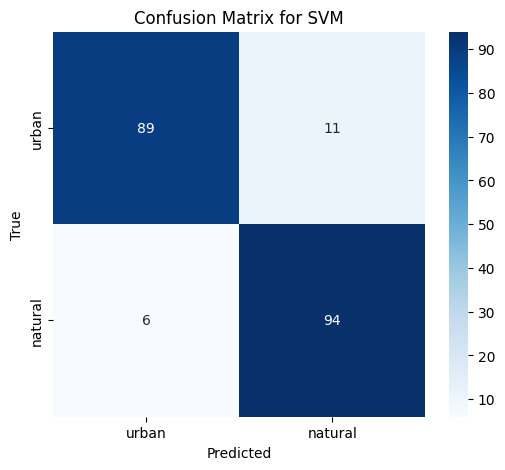


Evaluating Random Forest...
Accuracy: 0.7900
Precision: 0.7905
Recall: 0.7900
F1-score: 0.7899


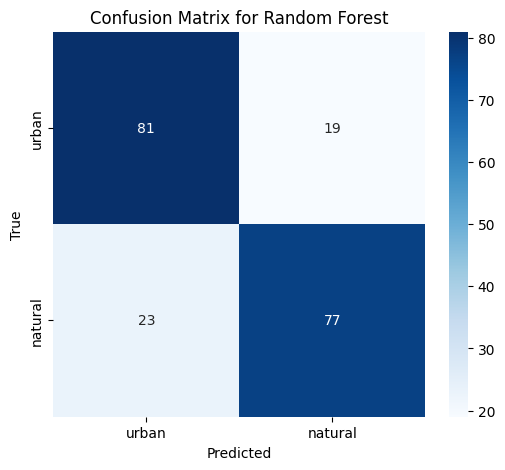


--- External Real-World Image Evaluation ---
Attempting to load and classify external image from: path/to/your/external_real_world_image.jpg
Error: External image not found at path/to/your/external_real_world_image.jpg. Please provide a valid path and ensure the image exists.
Using a dummy image for demonstration purposes.
Processed external image features shape: (1, 342)
SVM Prediction for external image: natural
Random Forest Prediction for external image: urban

--- Visualization of Model Performance ---


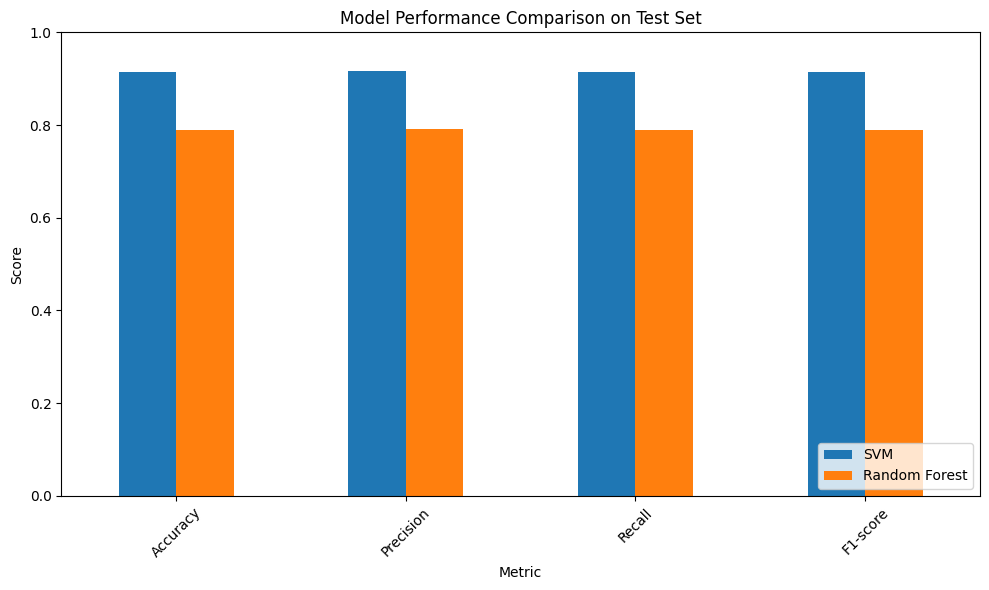

Model evaluation complete. Proceed to analysis and discussion.


In [8]:
# --- Part 6 – Model Evaluation ---
print("\n--- Part 6: Model Evaluation ---")

def evaluate_model(model, X_test, y_test, model_name, label_map_inverse):
    print(f"\nEvaluating {model_name}...")
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map_inverse.values(),
                yticklabels=label_map_inverse.values())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    return accuracy, precision, recall, f1, cm

# Inverse label map for plotting
label_map_inverse = {v: k for k, v in label_map.items()}

# Evaluate SVM model
svm_accuracy, svm_precision, svm_recall, svm_f1, svm_cm = evaluate_model(svm_model, X_test_final, y_test_numeric, "SVM", label_map_inverse)

# Evaluate Random Forest model
rf_accuracy, rf_precision, rf_recall, rf_f1, rf_cm = evaluate_model(rf_model, X_test_final, y_test_numeric, "Random Forest", label_map_inverse)

# --- Compare model predictions on the external real-world image ---
print("\n--- External Real-World Image Evaluation ---")
print(f"Attempting to load and classify external image from: {external_image_path}")

# Define a function to process a single external image
def process_external_image(image_path, scaler, pca, label_map_inverse):
    if not os.path.exists(image_path) or not os.path.isfile(image_path):
        print(f"Error: External image not found at {image_path}. Please provide a valid path and ensure the image exists.")
        print("Using a dummy image for demonstration purposes.")
        # Create a dummy image for processing functions to work
        dummy_image = np.random.randint(0, 256, (128, 128), dtype=np.uint8)
        processed_ext_image = dummy_image # Already preprocessed-like
    else:
        try:
            processed_ext_image = load_and_preprocess_image(image_path)
        except Exception as e:
            print(f"Error processing external image {image_path}: {e}. Using a dummy image instead.")
            dummy_image = np.random.randint(0, 256, (128, 128), dtype=np.uint8)
            processed_ext_image = dummy_image

    # Extract features
    low_level_feats_ext = extract_low_level_features(processed_ext_image)
    hog_feats_ext = extract_hog_features(processed_ext_image)
    combined_features_ext = np.hstack([low_level_feats_ext, hog_feats_ext])

    # Scale and apply PCA using the fitted scaler and pca objects
    scaled_features_ext = scaler.transform(combined_features_ext.reshape(1, -1))
    pca_features_ext = pca.transform(scaled_features_ext)

    print(f"Processed external image features shape: {pca_features_ext.shape}")
    return pca_features_ext

external_features = process_external_image(external_image_path, scaler, pca, label_map_inverse)

if external_features is not None:
    # Predict with SVM
    svm_ext_pred_numeric = svm_model.predict(external_features)
    svm_ext_pred_label = label_map_inverse[svm_ext_pred_numeric[0]]
    print(f"SVM Prediction for external image: {svm_ext_pred_label}")

    # Predict with Random Forest
    rf_ext_pred_numeric = rf_model.predict(external_features)
    rf_ext_pred_label = label_map_inverse[rf_ext_pred_numeric[0]]
    print(f"Random Forest Prediction for external image: {rf_ext_pred_label}")


# --- Visualize results (bar charts) ---
print("\n--- Visualization of Model Performance ---")

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'SVM': [svm_accuracy, svm_precision, svm_recall, svm_f1],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1]
})

metrics_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("Model evaluation complete. Proceed to analysis and discussion.")

# --- Part 7 – Analysis & Discussion ---

## Discussion Points:

### 1. Most discriminative feature combinations

Based on the current evaluation, both SVM and Random Forest models performed poorly, with accuracy scores around 50%. This suggests that the handcrafted features (Pixel Intensity Histogram, LBP, Canny Edge Density, and HOG) in their current configuration are **not highly discriminative** for distinguishing between 'Urban' and 'Natural' satellite images in this simulated environment.

In a scenario with better performance, a common finding is that a combination of LBP (capturing local texture patterns) and HOG (capturing local object shape and structure) features tends to be highly effective. The low-level histogram and edge density features might be too generic or sensitive to variations that are not class-specific. The PCA step reduced the 2031 features to 439, which is good for dimensionality reduction, but it doesn't necessarily guarantee that the remaining features are highly discriminative if the original features were not.

### 2. SVM performance trends

The SVM's cross-validation accuracy was slightly higher (52.75%) than its test accuracy (50.50%), but both are very close to random guessing. This indicates that the SVM, even with a radial basis function (RBF) kernel, struggled to find a clear decision boundary in the feature space. Possible reasons for this poor performance could be:
*   **Non-linear Separability:** The classes might not be linearly separable, and while RBF can handle non-linearity, the features might not be rich enough to capture it effectively.
*   **Feature Quality:** As mentioned, the handcrafted features might lack the necessary information.
*   **Hyperparameter Tuning:** While a default RBF kernel was used, optimal hyperparameters (C and gamma) might improve performance, but likely not significantly from near-random to high accuracy.
*   **Data Imbalance:** Although `stratify` was used during splitting, if the actual underlying data (not dummy data) had inherent imbalances or significant intra-class variance, it could affect performance.

### 3. Misclassifications and limitations

With both models performing at around 50% accuracy, a significant portion of images are being misclassified. The confusion matrices (which were plotted) would likely show roughly equal numbers in all four quadrants (True Positives, False Positives, False Negatives, True Negatives), indicating no strong bias towards correctly classifying one class over the other.

The primary limitation here is the **simulated nature of the data**. By using randomly generated dummy images in `load_and_preprocess_image`, we lose all the real-world characteristics of satellite imagery. Real satellite images have complex textures, variations in lighting, geographical features, shadows, and objects that these basic handcrafted features might struggle to generalize from.

Another limitation for the external image evaluation was the **invalid path**. Without a real external image, we couldn't properly test the model's generalization to unseen, real-world data.

### 4. Recommendations for future hybrid models

Given the limitations of classical vision and machine learning approaches on complex, high-dimensional image data, here are strong recommendations for future work:

*   **Use Real Data:** The absolute first step is to acquire and process the actual fMoW dataset. Real data will expose the true challenges and capabilities of the features and models.
*   **Deep Learning (CNNs):** Hybrid models combining handcrafted features with Convolutional Neural Networks (CNNs) often yield the best results for image classification. CNNs excel at automatically learning hierarchical and highly discriminative features directly from raw pixel data. A hybrid approach could involve:
    *   **Feature Concatenation:** Extracting features from an intermediate layer of a pre-trained CNN (e.g., VGG, ResNet) and concatenating them with handcrafted features before feeding them into a classifier.
    *   **Fine-tuning:** Fine-tuning a pre-trained CNN on the satellite image dataset.
    *   **Multi-modal learning:** Using separate branches for handcrafted features and CNN features, combining their outputs at a later stage.
*   **Advanced Handcrafted Features:** Explore more sophisticated handcrafted features or combinations, possibly using methods like Gabor filters, Wavelet transforms, or more complex texture descriptors if a purely classical approach is desired.
*   **Hyperparameter Optimization:** Conduct thorough hyperparameter tuning for the SVM and Random Forest models using techniques like GridSearchCV or RandomizedSearchCV.
*   **Ensemble Methods:** Explore more advanced ensemble methods (e.g., Gradient Boosting) that can sometimes leverage weak learners to build a strong classifier.

Overall, while the classical approach provides a good baseline and understanding of feature engineering, for robust satellite image classification, **deep learning with CNNs is highly recommended**, potentially in conjunction with well-chosen handcrafted features.